# FoldForge - Milestone 1: The 3D Fold Simulator

M0 told us *whether* a flat pattern can fold. M1 actually **folds it into 3D**.

The model (after Ghassaei, Demaine & Gershenfeld's Origami Simulator, 2018):

- the paper is split into rigid triangular **panels**, held rigid by stiff
  springs along every edge,
- each **crease** is a hinge that we drive toward a target fold angle,
- we relax the whole thing to equilibrium while ramping the fold from flat to
  folded.

A rigid fold should keep every panel its original size, so we track the worst
**bar strain** as a built-in honesty check: it should stay near zero.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from foldforge.geometry import examples
from foldforge.geometry.render import render_folded
from foldforge.sim import FoldMesh, fold, creases_along_x

mesh = FoldMesh.from_pattern(examples.miura(4, 4))
mesh   # triangulated, with bars + hinges

FoldMesh(vertices=array([[0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [2.  , 0.  , 0.  ],
       [3.  , 0.  , 0.  ],
       [4.  , 0.  , 0.  ],
       [0.35, 0.8 , 0.  ],
       [1.35, 0.8 , 0.  ],
       [2.35, 0.8 , 0.  ],
       [3.35, 0.8 , 0.  ],
       [4.35, 0.8 , 0.  ],
       [0.  , 1.6 , 0.  ],
       [1.  , 1.6 , 0.  ],
       [2.  , 1.6 , 0.  ],
       [3.  , 1.6 , 0.  ],
       [4.  , 1.6 , 0.  ],
       [0.35, 2.4 , 0.  ],
       [1.35, 2.4 , 0.  ],
       [2.35, 2.4 , 0.  ],
       [3.35, 2.4 , 0.  ],
       [4.35, 2.4 , 0.  ],
       [0.  , 3.2 , 0.  ],
       [1.  , 3.2 , 0.  ],
       [2.  , 3.2 , 0.  ],
       [3.  , 3.2 , 0.  ],
       [4.  , 3.2 , 0.  ]]), triangles=array([[ 0,  1,  6],
       [ 0,  6,  5],
       [ 1,  2,  7],
       [ 1,  7,  6],
       [ 2,  3,  8],
       [ 2,  8,  7],
       [ 3,  4,  9],
       [ 3,  9,  8],
       [ 5,  6, 11],
       [ 5, 11, 10],
       [ 6,  7, 12],
       [ 6, 12, 11],
       [ 7,  8, 13],
       [ 7, 13, 12],
 

## 1. Fold a Miura-ori

A Miura is a **1-degree-of-freedom mechanism**: we only need to drive one crease
family (the horizontal "major" folds) and the zig-zag folds follow along. That's
what `creases_along_x(mesh)` selects.

worst face strain over the whole fold: 0.63%


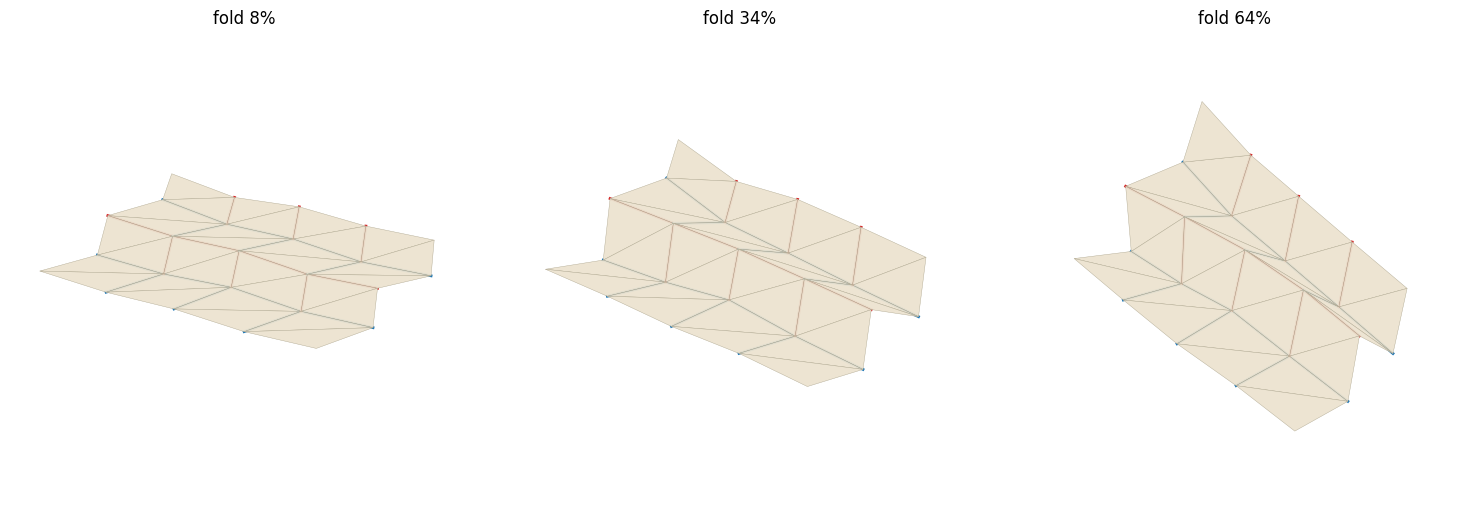

In [2]:
result = fold(mesh, fold_fraction=0.85, actuate=creases_along_x(mesh))
print("worst face strain over the whole fold:", f"{result.max_strain:.2%}")

fig = plt.figure(figsize=(15, 5))
for k, idx in enumerate([3, 15, 29]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    render_folded(mesh, result.frames[idx], ax=ax,
                  title=f"fold {result.fractions[idx]:.0%}")
plt.tight_layout()
plt.show()

## 2. Did the panels stay rigid?

If the simulator were stretching the paper, the strain would climb as we fold.
Instead it stays around a percent - the panels stay (almost exactly) their
original size all the way down.

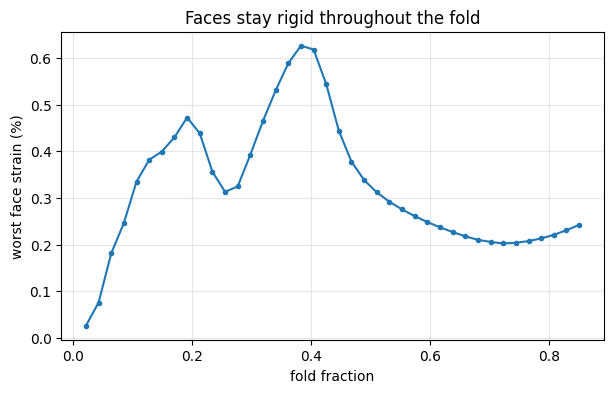

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(result.fractions, result.strains * 100, marker="o", ms=3)
plt.xlabel("fold fraction"); plt.ylabel("worst face strain (%)")
plt.title("Faces stay rigid throughout the fold")
plt.grid(alpha=0.3); plt.show()

## 3. A different pattern: the waterbomb base

The waterbomb base is a single-vertex 3D base (the one M0 flagged as *not*
flat-foldable). Here we drive all its creases and watch it pop into 3D.

waterbomb worst strain: 0.18%


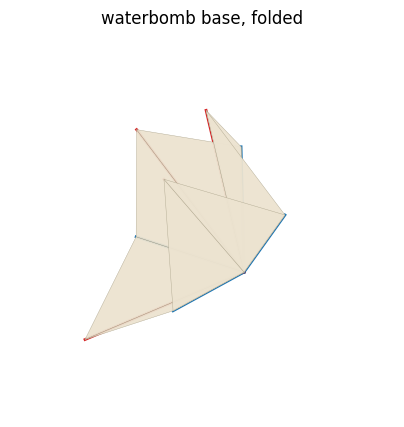

In [4]:
wb = FoldMesh.from_pattern(examples.waterbomb_base())
wb_result = fold(wb, fold_fraction=0.7)
print("waterbomb worst strain:", f"{wb_result.max_strain:.2%}")

ax = plt.figure(figsize=(5, 5)).add_subplot(111, projection="3d")
render_folded(wb, wb_result.vertices, ax=ax, title="waterbomb base, folded")
plt.show()

## Recap

- A flat crease pattern becomes a rigid-panel mesh and folds into 3D.
- The fold is driven by hinge forces and kept rigid by length projection; the
  strain plot is the proof it stayed rigid (~1%).
- The same solver folds a Miura tessellation and a single-vertex base.

**Limitations (honest):** panels can pass through each other at deep folds (no
self-intersection test yet), and the relaxation finds *a* rigid fold rather than
a guaranteed-unique one.

**Next (M2):** rebuild this solver on autodiff tensors so we can backpropagate
through the fold - the gateway to inverse design.